### Import Libraries

In [1]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import afterglowpy as grb
from astropy import units as u
from scipy.optimize import curve_fit

# 1. Check model

### Set Parameters


In [2]:
day = 86400.0

jetType = 2 # Gaussian
specType = 0 # synchroton 

thV_degree=20. #  observer angle 
thV = 3.14*thV_degree/180.  # so it is about 
thC = 0.07   # so it is about 5 deg
thW = 15./180.*3.14   # 15 deg 

p = 2.17
epse = 10.**(-1.3)
epsB = 10.**(-2.4)


E0 = 1.0e52 
L0 = 1.0e47 
q = 1.0  
ts = 1.0e5
n0 = 1.0e-4
ksiN = 1.0
d_L = 1.23e26 # 40 Mpc

Y = np.array([thV, E0, thC, thW, L0, q, ts, n0, p, epse, epsB, ksiN, d_L])

Z = {'jetType':     jetType,     # 
     'specType':    specType,                  # Basic Synchrotron Emission Spectrum
     'thetaObs':    thV,   # Viewing angle in radians
     'E0':          E0, # Isotropic-equivalent energy in erg
     'thetaCore':   thC,    # Half-opening angle in radians
     'thetaWing':   thW,    # Outer truncation angle
     'n0':          n0,    # circumburst density in cm^{-3}
     'p':           p,    # electron energy distribution index
     'epsilon_e':   epse,    # epsilon_e
     'epsilon_B':   epsB,   # epsilon_B
     'xi_N':        ksiN,    # Fraction of electrons accelerated
     'd_L':         d_L, # Luminosity distance in cm
     'z':           0.0099}   # redshift



### Set time range and energy bands

In [3]:
ta = 1.0e0 * day
tb = 1.0e3 * day
t = np.logspace(np.log10(ta), np.log10(tb), base=10.0, num=25)

nuRadio = np.empty(t.shape)
nuF814W  = np.empty(t.shape)
nuF606W  = np.empty(t.shape)
nuX  = np.empty(t.shape)

nuRadio[:] = 3.0e9
nuF814W[:] = (8369.51*u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value
#http://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?id=HST/WFPC2.f814w
nuF606W[:] = (5778.32*u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value
#http://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?id=HST/ACS_HRC.F606W&&mode=browse&gname=HST&gname2=ACS_HRC#filter
nuX[:] = (1.*u.keV).to(u.Hz, equivalencies=u.spectral()).value

nu_arr=(nuRadio,nuF814W,nuF606W,nuX)

labels=['3 GHz','F814W','F606W','1keV']


### Calcuate the flux

In [4]:
Fth_radio = grb.fluxDensity(t, nuRadio, **Z)
Fth_f814w = grb.fluxDensity(t, nuF814W, **Z)
Fth_f606w = grb.fluxDensity(t, nuF606W, **Z)
Fth_X = grb.fluxDensity(t, nuX,  **Z)

In [5]:
Fnu_arr=(Fth_radio,Fth_f814w,Fth_f606w,Fth_X)


### Plot the light curve

Saving figure lc.png


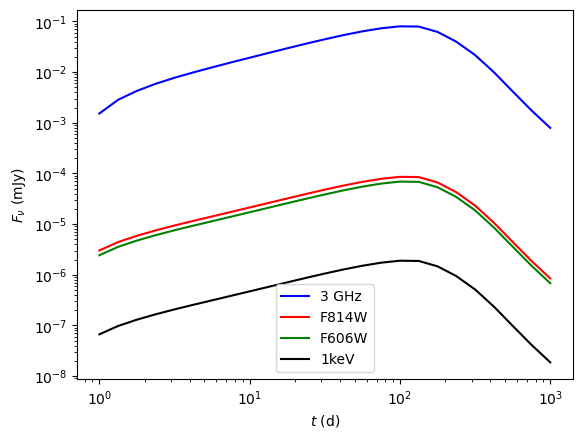

In [6]:

fig, ax = plt.subplots(1,1)
thVs = [0.4]
colors=['blue','r','green','black']
i=0
for nu_ in nu_arr:
    nu_now=nu_
    Fnu = Fnu_arr[i]
    ax.plot(t/day, Fnu,color=colors[i])
    i=i+1
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$t$ (d)')
ax.set_ylabel(r'$F_\nu$ (mJy)')

plt.legend(('3 GHz', 'F814W', 'F606W','1keV'),loc='best')
print("Saving figure lc.png")
# fig.savefig("lc_multi.png")
plt.show()

# 2. Comapre with data

### Read in Data

In [7]:
t_xray, f_xray = np.loadtxt('x_ray.txt', usecols=(0, 1), unpack=True)
t_radio, f_radio = np.loadtxt('radio.txt', usecols=(0, 1), unpack=True)
t_f814w, f_f814w = np.loadtxt('f814w.txt', usecols=(0, 1), unpack=True)
t_f606w, f_f606w = np.loadtxt('f606w.txt', usecols=(0, 1), unpack=True)



nu_radio = np.empty(t_radio.shape)
nu_f814w  = np.empty(t_f814w.shape)
nu_f606w  = np.empty(t_f606w.shape)
nu_X  = np.empty(t_xray.shape)

nu_radio[:] = 3.0e9
nu_f814w[:] = (8369.51*u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value
#http://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?id=HST/WFPC2.f814w
nu_f606w[:] = (5778.32*u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value
#http://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?id=HST/ACS_HRC.F606W&&mode=browse&gname=HST&gname2=ACS_HRC#filter
nu_X[:] = (1.*u.keV).to(u.Hz, equivalencies=u.spectral()).value





### Compare

Saving figure lc.png


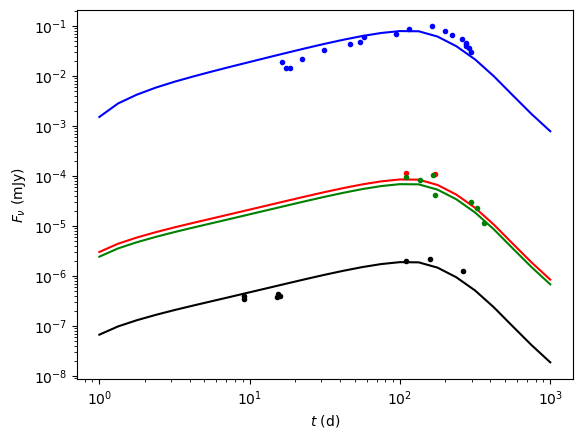

In [8]:

fig, ax = plt.subplots(1,1)
thVs = [0.4]
colors=['blue','r','green','black']
i=0
for nu_ in nu_arr:
    #Y[0] = thV
    nu_now=nu_
    Fnu = Fnu_arr[i]
    ax.plot(t/day, Fnu,color=colors[i])
    i=i+1
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$t$ (d)')
ax.set_ylabel(r'$F_\nu$ (mJy)')

ax.plot(t_radio, f_radio,'.',color='blue')
ax.plot(t_f814w, f_f814w,'.',color='r')
ax.plot(t_f606w, f_f606w,'.',color='green')
ax.plot(t_xray, f_xray,'.',color='black')

#plt.legend(('3 GHz', 'F814W', 'F606W','1keV'),loc='best')
print("Saving figure lc.png")
fig.savefig("lc_multi_with_obs.png")
plt.show()

# 3. Fit 

## 3.1 Model with 6 free parameters

### Define Model


In [9]:
def model(x, thV,thC,log_ee,log_eb,log_E0,log_n0):
    jetType = 2 # Gaussian
    specType = 0 # synchroton 
    thW = 15./180.*3.14   # 15 deg 
    epse = 10.**(log_ee)
    epsB = 10.**(log_eb)
    E0 = 10.0**log_E0 
    L0 = 1.e47 #10.0**log_L0
    q = 1.0  
    ts = 1.0e5
    n0 = 10.**(log_n0)
    ksiN = 1.0
    dL = 1.23e26 # 40 Mpc
    p=2.1
    Y = np.array([thV, E0, thC, thW, L0, q, ts, n0, p, epse, epsB, ksiN, dL])
    Z = {'jetType':     jetType,     # 
     'specType':    specType,                  # Basic Synchrotron Emission Spectrum
     'thetaObs':    thV,   # Viewing angle in radians
     'E0':          E0, # Isotropic-equivalent energy in erg
     'thetaCore':   thC,    # Half-opening angle in radians
     'thetaWing':   thW,    # Outer truncation angle
     'n0':          n0,    # circumburst density in cm^{-3}
     'p':           p,    # electron energy distribution index
     'epsilon_e':   epse,    # epsilon_e
     'epsilon_B':   epsB,   # epsilon_B
     'xi_N':        ksiN,    # Fraction of electrons accelerated
     'd_L':         d_L, # Luminosity distance in cm
     'z':           0.0099}   # redshift
    t_day, frequency = x
    t_seconds=t_day*86400.0
    flux_denstiy=grb.fluxDensity(t_seconds, frequency, **Z)
    return flux_denstiy

### Prepare Observations

In [10]:
all_time=np.concatenate((t_radio,t_f814w,t_f606w,t_xray),axis=None)
all_freq=np.concatenate((nu_radio,nu_f814w,nu_f606w,nu_X), axis=None)
x = np.row_stack([
    all_time,
    all_freq
])
y = np.concatenate((f_radio,f_f814w,f_f606w,f_xray),axis=None)
sigma = 0.2*np.abs(y)

### Fit

In [11]:
thV_degree=20. #  observer angle 
thV = 3.14*thV_degree/180.  # so it is about 
thC = 0.07   # so it is about 5 deg
thW = 15./180.*3.14   # 15 deg 
p = 2.17
epse = 10.**(-1.3)
epsB = 10.**(-2.4)
E0 = 1.0e52 
L0 = 1.0e47 
ts = 1.0e5
n0 = 1.0e-4
ksiN = 1.0
dL = 1.23e26 # 40 Mpc
guess_par=[thV,thC,-1.3,-2.4,52.,-4.]
range_1=   [3.14*15/180.,0.01,-4.,-4.,48,-6.]
range_2= [3.14*30.0/180.,0.15,-1.,-1.,55.,-1.]

popt, pcov = curve_fit(model, x, y,guess_par, sigma,bounds=(range_1,range_2) )

perr = np.sqrt(np.diag(pcov))


### Output the best-fit parameters:

In [12]:
for name, popt_, perr_ in zip(['thV','thC','log_ee','log_eb','log_E0','log_n0'], popt, perr):
    print(u'{:2s} = {} ± {}'.format(name, popt_, perr_))

thV = 0.3467777663277886 ± 0.01640998039162424
thC = 0.06785694584926243 ± 0.0017913778599379605
log_ee = -1.2768998011146295 ± 15.723720367472703
log_eb = -2.4420681410721734 ± 22.31584651960156
log_E0 = 52.13517046292502 ± 0.06952493381352066
log_n0 = -4.1701688946261815 ± 0.08424718167735912


### Plot the fit 

In [13]:
Y_th=np.array([popt[0], 10.**popt[4], popt[1], 15./180.*3.14, 1.0e47 , 1, 1.e5, 10.**popt[5], 2.1, 10.**popt[2], 10.**popt[3], 1.0,1.23e26])
#Y = np.array([thV, E0, thC, thW, L0, q, ts, n0, p, epse, epsB, ksiN, dL])
Z_th = {'jetType':   jetType,     # 
     'specType':    specType,                  # Basic Synchrotron Emission Spectrum
     'thetaObs':    Y_th[0],   # Viewing angle in radians
     'E0':          Y_th[1], # Isotropic-equivalent energy in erg
     'thetaCore':   Y_th[2],    # Half-opening angle in radians
     'thetaWing':   Y_th[3],    # Outer truncation angle
     'n0':          Y_th[7],    # circumburst density in cm^{-3}
     'p':           Y_th[8],    # electron energy distribution index
     'epsilon_e':   Y_th[9],    # epsilon_e
     'epsilon_B':   Y_th[10],   # epsilon_B
     'xi_N':        Y_th[11],    # Fraction of electrons accelerated
     'd_L':        Y_th[12], # Luminosity distance in cm
     'z':           0.0099}   # redshift
#print(Z_th,Z)
Fth_radio = grb.fluxDensity(t, nuRadio,  **Z_th)
Fth_f814w = grb.fluxDensity(t, nuF814W,  **Z_th)
Fth_f606w = grb.fluxDensity(t, nuF606W,  **Z_th)
Fth_X = grb.fluxDensity(t, nuX, **Z_th)

Saving figure lc.png


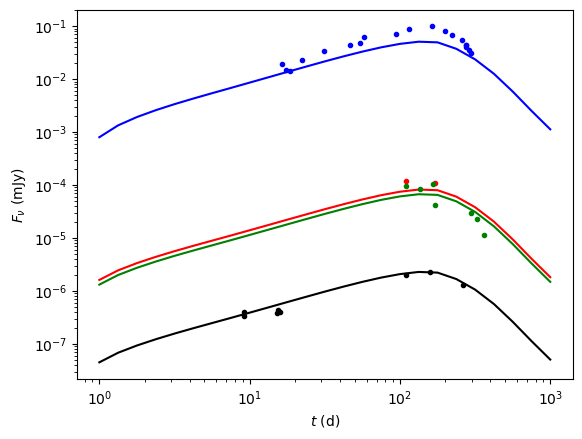

In [14]:
Fnu_arr=(Fth_radio,Fth_f814w,Fth_f606w,Fth_X)

fig, ax = plt.subplots(1,1)
colors=['blue','r','green','black']
i=0
for nu_ in nu_arr:
    #Y[0] = thV
    nu_now=nu_
    Fnu = Fnu_arr[i]
    ax.plot(t/day, Fnu,color=colors[i])
    i=i+1
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$t$ (d)')
ax.set_ylabel(r'$F_\nu$ (mJy)')

ax.plot(t_radio, f_radio,'.',color='blue')
ax.plot(t_f814w, f_f814w,'.',color='r')
ax.plot(t_f606w, f_f606w,'.',color='green')
ax.plot(t_xray, f_xray,'.',color='black')

#plt.legend(('3 GHz', 'F814W', 'F606W','1keV'),loc='best')
print("Saving figure lc.png")
fig.savefig("fit_6par.png")
plt.show()

## 3.2 Model with 9 free parameters (YOYO)